In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
DATA_PATH = "/Users/animeshdash/PycharmProjects/RoboLinReg/data/linear_regression_dataset.csv"
df = pd.read_csv(DATA_PATH)
df

,AGE,FEMALE,LOS,RACE,TOTCHG,APRDRG
0,17,1,2,1.0,2660,560
1,17,0,2,1.0,1689,753
2,17,1,7,1.0,20060,930
3,17,1,1,1.0,736,758
4,17,1,1,1.0,1194,754
...,...,...,...,...,...,...
495,0,1,6,1.0,5881,636
496,0,1,2,1.0,1171,640
497,0,1,2,1.0,1171,640
498,0,1,2,1.0,1086,640


In [3]:
print(df.head())
print(df.info())
print(df.describe())

   AGE  FEMALE  LOS  RACE  TOTCHG  APRDRG
0   17       1    2   1.0    2660     560
1   17       0    2   1.0    1689     753
2   17       1    7   1.0   20060     930
3   17       1    1   1.0     736     758
4   17       1    1   1.0    1194     754
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     500 non-null    int64  
 1   FEMALE  500 non-null    int64  
 2   LOS     500 non-null    int64  
 3   RACE    499 non-null    float64
 4   TOTCHG  500 non-null    int64  
 5   APRDRG  500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB
None
              AGE      FEMALE         LOS        RACE        TOTCHG  \
count  500.000000  500.000000  500.000000  499.000000    500.000000   
mean     5.086000    0.512000    2.828000    1.078156   2774.388000   
std      6.949474    0.500357    3.363487    0.514746   3888.407367   
min      0.000000  

In [4]:
df.fillna(df.mean(), inplace=True)
df.isna().sum()

AGE       0
FEMALE    0
LOS       0
RACE      0
TOTCHG    0
APRDRG    0
dtype: int64

In [5]:
X = df.drop(columns=["TOTCHG"]).values
y = df["TOTCHG"].values

In [6]:
np.random.seed(42)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

In [7]:
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train = X[:split_index]
X_test  = X[split_index:]
y_train = y[:split_index]
y_test  = y[split_index:]

In [8]:
# --- Scale X only (y stays in original units) ---
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
std[std == 0] = 1

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

print("X_train mean (should be ~0):", X_train.mean(axis=0).round(6))
print("X_train std  (should be ~1):", X_train.std(axis=0).round(6))
print("y_train mean (unscaled)     :", y_train.mean().round(2))

X_train mean (should be ~0): [-0. -0.  0. -0. -0.]
X_train std  (should be ~1): [1. 1. 1. 1. 1.]
y_train mean (unscaled)     : 2700.48


In [9]:
def predict(X, w, b):
    return np.dot(X, w) + b

def MSE(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def r2_score(y_pred, y_true):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

def compute_gradients(X, y_pred, y_true):
    m = X.shape[0]
    error = y_pred - y_true
    dw = (2 / m) * np.dot(X.T, error)
    db = (2 / m) * error.sum()
    return dw, db

In [10]:
def train(X, y, lr=1e-3, tolerance=1e-6, max_iter=200000, print_every=100):

    X = X.astype(float)
    y = y.astype(float)

    m_samples, n_features = X.shape
    w = np.zeros(n_features, dtype=float)
    b = 0.0

    cost_history  = []
    r2_history    = []
    epoch_ticks   = []

    # Header for per-epoch report
    print(f"{'Epoch':>8}  {'MSE':>15}  {'RMSE':>12}  {'R²':>8}")
    print("-" * 52)

    for iteration in range(max_iter):
        y_pred = predict(X, w, b)
        dw, db = compute_gradients(X, y_pred, y)

        w_prev = w.copy()
        b_prev = b

        w -= lr * dw
        b -= lr * db

        # Record & print metrics every print_every steps
        if print_every and iteration % print_every == 0:
            cost = MSE(y_pred, y)
            rmse = np.sqrt(cost)
            r2   = r2_score(y_pred, y)

            cost_history.append(cost)
            r2_history.append(r2)
            epoch_ticks.append(iteration)

            print(f"{iteration:>8}  {cost:>15.6f}  {rmse:>12.6f}  {r2:>8.6f}")

        # Convergence check
        if np.linalg.norm(w - w_prev) < tolerance and abs(b - b_prev) < tolerance:
            # Record final state at convergence
            cost = MSE(predict(X, w, b), y)
            rmse = np.sqrt(cost)
            r2   = r2_score(predict(X, w, b), y)
            cost_history.append(cost)
            r2_history.append(r2)
            epoch_ticks.append(iteration)
            print("-" * 52)
            print(f"✓ Converged at iteration {iteration}")
            print(f"  Final MSE : {cost:.6f}")
            print(f"  Final RMSE: {rmse:.6f}")
            print(f"  Final R²  : {r2:.6f}")
            break
    else:
        print("Reached max iterations without full convergence.")

    return w, b, cost_history, r2_history, epoch_ticks

In [11]:
w_learned, b_learned, cost_history, r2_history, epoch_ticks = train(
    X_train, y_train, lr=0.01, print_every=100
)

   Epoch              MSE          RMSE        R²
----------------------------------------------------
       0  22393145.872500   4732.139672  -0.482934
     100   8276864.300428   2876.953997  0.451884
     200   7983907.969966   2825.580997  0.471284
     300   7977109.500439   2824.377719  0.471734
     400   7976933.228207   2824.346513  0.471746
     500   7976928.116744   2824.345609  0.471746
     600   7976927.951305   2824.345579  0.471746
     700   7976927.945341   2824.345578  0.471746
     800   7976927.945103   2824.345578  0.471746
     900   7976927.945092   2824.345578  0.471746
    1000   7976927.945092   2824.345578  0.471746
----------------------------------------------------
✓ Converged at iteration 1069
  Final MSE : 7976927.945092
  Final RMSE: 2824.345578
  Final R²  : 0.471746


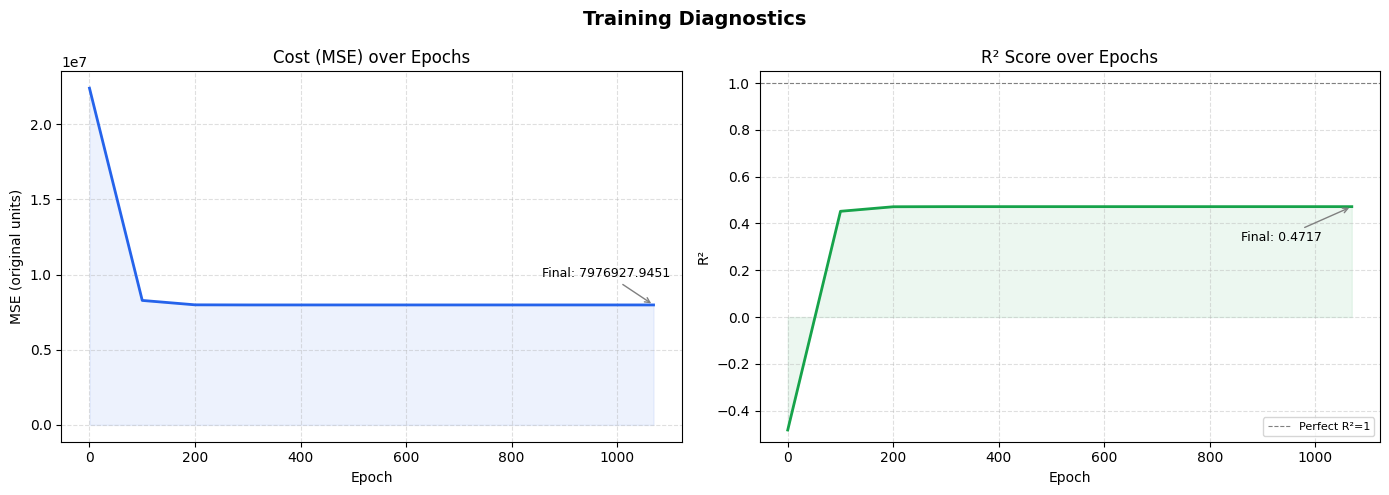

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Diagnostics", fontsize=14, fontweight="bold")

# --- Left: Cost (MSE) curve ---
ax1 = axes[0]
ax1.plot(epoch_ticks, cost_history, color="#2563eb", linewidth=2)
ax1.fill_between(epoch_ticks, cost_history, alpha=0.08, color="#2563eb")
ax1.set_title("Cost (MSE) over Epochs", fontsize=12)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE (original units)")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.annotate(
    f"Final: {cost_history[-1]:.4f}",
    xy=(epoch_ticks[-1], cost_history[-1]),
    xytext=(-80, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=9,
)

# --- Right: R² curve ---
ax2 = axes[1]
ax2.plot(epoch_ticks, r2_history, color="#16a34a", linewidth=2)
ax2.fill_between(epoch_ticks, r2_history, alpha=0.08, color="#16a34a")
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Perfect R²=1")
ax2.set_title("R² Score over Epochs", fontsize=12)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("R²")
ax2.set_ylim(min(r2_history) - 0.05, 1.05)
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend(fontsize=8)
ax2.annotate(
    f"Final: {r2_history[-1]:.4f}",
    xy=(epoch_ticks[-1], r2_history[-1]),
    xytext=(-80, -25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=9,
)

plt.tight_layout()
plt.savefig("training_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Predictions
y_pred_test = predict(X_test, w_learned, b_learned)

# Metrics in original units
mse_test  = MSE(y_pred_test, y_test)
rmse_test = np.sqrt(mse_test)
r2_test   = r2_score(y_pred_test, y_test)
mae_test  = np.mean(np.abs(y_pred_test - y_test))

print("=" * 40)
print("      TEST SET EVALUATION")
print("=" * 40)
print(f"  MSE  : {mse_test:>15.2f}")
print(f"  RMSE : {rmse_test:>15.2f}")
print(f"  MAE  : {mae_test:>15.2f}")
print(f"  R²   : {r2_test:>15.6f}")
print("=" * 40)

      TEST SET EVALUATION
  MSE  :      2065867.68
  RMSE :         1437.31
  MAE  :          971.86
  R²   :        0.861684
